In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import qmc
from sklearn.preprocessing import StandardScaler

## Practica 3: Emulator for luminosity distance

#### 2 Train a Neural Network for the luminosity distance

In [2]:
# Generate a function that calculate the luminosity distance for a given redshift, a H0 and a Ωm value.



# constants for units 
c = 299792.458 # speed of light in km/s
H0 = 70.0 # Hubble constant in km/s/Mpc
Omega_m = 0.3 # Matter density parameter
Omega_L = 0.7 # Dark energy density parameter


def E(z):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def luminosity_distance(z, H0, Omega_m):
    # Calculate the luminosity distance using the formula:
    # d_L = (c / H0) * (1 + z) * integral from 0 to z of dz' / E(z')
    integral, _ = quad(lambda z_prime: 1 / E(z_prime), 0, z)
    
    # Calculate the luminosity distance
    d_L = (c / H0) * (1 + z) * integral
    return d_L


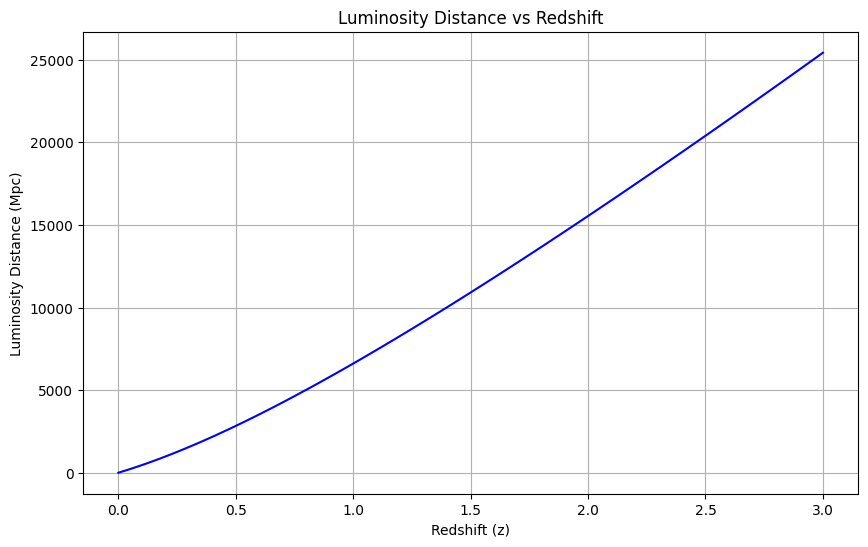

In [3]:
z_values = np.linspace(0.001, 3, 100)  

d_L_values = [luminosity_distance(z, H0, Omega_m) for z in z_values]

plt.figure(figsize=(10, 6))
plt.plot(z_values, d_L_values, label='Luminosity Distance', color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.show()

In [4]:
'''
Create trainning and validation samples that covers z ∈ (0, 3), H0 ∈ (60, 85), and Ωm ∈ (0.1, 0.5). This
time, we do not give you the size of the samples, you have to define it.
'''

# Here we use the Latin Hypercube Sampling algorithm to generate the training and validation samples. 
# This algorithm allows us to sample the parameter space more efficiently than random sampling.

# [z, H0, Omega_m]
lower_bounds = [0.0, 60.0, 0.1]
upper_bounds = [3.0, 85.0, 0.5]

# sample sizes
n_train = 800
n_val = 200





In [5]:
sampler = qmc.LatinHypercube(d=3)




# Train Samples
sample_train_unscaled = sampler.random(n=n_train)
sample_train = qmc.scale(sample_train_unscaled, lower_bounds, upper_bounds)
z_train, H0_train, Omega_m_train = sample_train[:, 0], sample_train[:, 1], sample_train[:, 2]

# Val Samples
sample_val_unscaled = sampler.random(n=n_val)
sample_val = qmc.scale(sample_val_unscaled, lower_bounds, upper_bounds)
z_val, H0_val, Omega_m_val = sample_val[:, 0], sample_val[:, 1], sample_val[:, 2]



In [6]:
# Targets
d_L_train = np.array([luminosity_distance(z, H0, Omega_m) for z, H0, Omega_m in zip(z_train, H0_train, Omega_m_train)])
d_L_val = np.array([luminosity_distance(z, H0, Omega_m) for z, H0, Omega_m in zip(z_val, H0_val, Omega_m_val)])



In [7]:
# 1. Scale the Inputs (z, H0, Omega_m)
input_scaler = StandardScaler()
X_train_scaled = input_scaler.fit_transform(sample_train)
X_val_scaled = input_scaler.transform(sample_val)

# 2. Scale the Outputs (Luminosity Distance)
# StandardScaler expects a 2D array, so we reshape from (N,) to (N, 1)
output_scaler = StandardScaler()
Y_train_scaled = output_scaler.fit_transform(d_L_train.reshape(-1, 1))
Y_val_scaled = output_scaler.transform(d_L_val.reshape(-1, 1))

In [8]:
# check the shapes and ranges of the re scaled data to ensure everything is correct before training the model.
print(f"Train shapes: z={X_train_scaled.shape}, H0={H0_train.shape}, Omega_m={Omega_m_train.shape}")
print(f"H0 Train Min/Max: {H0_train.min():.2f} / {H0_train.max():.2f}")
print(f"Val shapes: z={X_val_scaled.shape}, H0={H0_val.shape}, Omega_m={Omega_m_val.shape}")
print(f"H0 Val Min/Max: {H0_val.min():.2f} / {H0_val.max():.2f}")

Train shapes: z=(800, 3), H0=(800,), Omega_m=(800,)
H0 Train Min/Max: 60.02 / 84.98
Val shapes: z=(200, 3), H0=(200,), Omega_m=(200,)
H0 Val Min/Max: 60.10 / 84.97


In [9]:
# --- Neural Network ---
model = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# Train the model on the SCALED data
history = model.fit(
    x=X_train_scaled, 
    y=Y_train_scaled, 
    validation_data=(X_val_scaled, Y_val_scaled),
    epochs=100, 
    batch_size=32,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8008 - val_loss: 0.1729
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1023 - val_loss: 0.0108
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0095 - val_loss: 0.0038
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 9.9778e-04
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss:

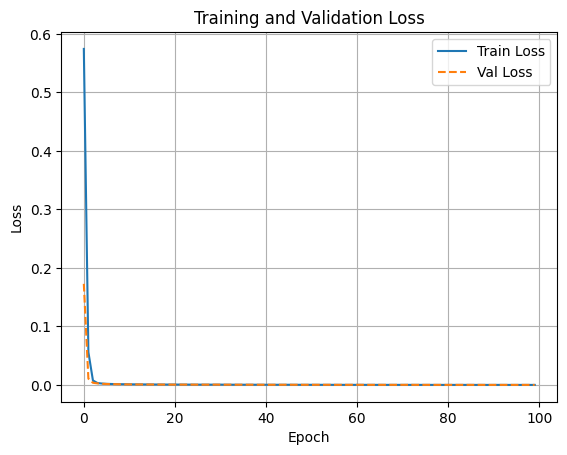

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

### Create an emulator of the distance modulus
#### using the formula 
$$

\mu  = 5 \log_{10} \left( \frac{D_L(z)}{10\; pc}\right)
$$

In [12]:
# 5) Generate the Training and Validation set for the distance modulus for the same range of redshift, H0, and a Ωm.

distance_modulus_train = 5 * np.log10(d_L_train * 1e6 / 10)  # Convert Mpc to pc and apply the formula
distance_modulus_val = 5 * np.log10(d_L_val * 1e6 / 10)  # Convert Mpc to pc and apply the formula